In [103]:
import pandas as pd

###`Q-1:` Write a program to create an empty series.

In [104]:
emppty_series = pd.Series()

emppty_series

Series([], dtype: object)

###`Q-2:` Write a Pandas program to add, subtract, multiple and divide two Pandas Series.

In [105]:
series_1 = pd.Series([2, 4, 6, 8, 10])
series_2 = pd.Series([1, 3, 5, 7, 10])

# Add two pandas series
add = series_1 + series_2
print("Added series:\n", add)

# subtract two pandas series
sub = series_1 - series_2
print("Subtracted series value\n", sub)

# multiply two pandas series
mul = series_1 * series_2
print("Multiplied value", mul)

# Divided value. 
div = series_1 / series_2
print("Div", div)

Added series:
 0     3
1     7
2    11
3    15
4    20
dtype: int64
Subtracted series value
 0    1
1    1
2    1
3    1
4    0
dtype: int64
Multiplied value 0      2
1     12
2     30
3     56
4    100
dtype: int64
Div 0    2.000000
1    1.333333
2    1.200000
3    1.142857
4    1.000000
dtype: float64


###`Q-3` Write a Pandas program to compare the elements of the two Pandas Series.
Sample Series: [2, 4, 6, 8, 10], [1, 3, 5, 7, 10]



In [106]:
series_1 = pd.Series([2, 4, 6, 8, 10])
series_2 = pd.Series([1, 3, 5, 7, 10])

series_2 == series_1

0    False
1    False
2    False
3    False
4     True
dtype: bool

###`Q-5.`Write a function to change the data type of given a column or a Series. Function takes series and data type as input, returns the converted series.
```
series = pd.Series([1,2,'Python', 2.0, True, 100])
change to float type data
```
Note: Read about pd.to_numeric()

In [107]:
def change_data_type(series, target_type):
    """
    Changes the data type of a Series. 
    Coerces errors to NaN for numeric conversions.
    """
    if target_type in ['float', 'int', 'float64', 'int64']:
        return pd.to_numeric(series, errors='coerce').astype(target_type)
    
    return series.astype(target_type)

# Initializing your sample series
series = pd.Series([1, 2, 'Python', 2.0, True, 100])

# Executing the conversion to float
converted_series = change_data_type(series, 'str')

print("Original Series:\n", series)
print("\nConverted Series:\n", converted_series)

Original Series:
 0         1
1         2
2    Python
3       2.0
4      True
5       100
dtype: object

Converted Series:
 0         1
1         2
2    Python
3       2.0
4      True
5       100
dtype: str


Download data - https://drive.google.com/file/d/1LRhXwbEodeWXtzPhJCX0X9Lf_BECzvqb/view?usp=share_link
All Batsman runs series in IPL 2008 to 2022.

Below questions are based on this data.

###`Q-6` Find top 10 most run getter from the series.

In [108]:
import os 

cwd = os.getcwd()
batsman_runs_series = pd.read_csv(os.path.join(cwd, 'batsman_runs_series.csv'), index_col='batter').squeeze()
batsman_runs_series

batter
A Ashish Reddy     280
A Badoni           161
A Chandila           4
A Chopra            53
A Choudhary         25
                  ... 
Yash Dayal           0
Yashpal Singh       47
Younis Khan          3
Yuvraj Singh      2754
Z Khan             117
Name: batsman_run, Length: 605, dtype: int64

In [109]:
sorted_runs_data = batsman_runs_series.sort_values()
sorted_runs_data.tail(10)

batter
KD Karthik        4377
RV Uthappa        4954
MS Dhoni          4978
CH Gayle          4997
AB de Villiers    5181
SK Raina          5536
RG Sharma         5881
DA Warner         5883
S Dhawan          6244
V Kohli           6634
Name: batsman_run, dtype: int64

###`Q-7` No of players having runs above 3000

In [110]:
batsman_runs_series[batsman_runs_series > 3000].size

20

###`Q-8` No of players having runs above mean value?

In [111]:
runs_mean = batsman_runs_series.mean()

batsman_runs_series[batsman_runs_series > runs_mean].size

128

###`Q-9`
    
i. Read `items.csv` and set `item_name` as the index

ii. Show the number of NaN values

iii. Convert `item_price` from `$` to rupees (remove `$` and convert currency)

iv. Change the datatype of the new series to `float`

v. Fill NaN values with the mean of the series



How csv file looks

```
item_name	item_price
Chips and Fresh Tomato Salsa	$2.39
Izze	$3.39
Nantucket Nectar	$3.39
Chips and Tomatillo-Green Chili Salsa	$2.39
Chicken Bowl	$16.98

```

Download data - https://drive.google.com/file/d/1QZuZ5bypUInfVvarHACLAi8tXXHvb8xd/view?usp=share_link

file name - items.csv



In [112]:
# i. Read `items.csv` and set `item_name` as the index
items_series = pd.read_csv(os.path.join(cwd, 'items.csv'), index_col='item_name').squeeze()
items_series

item_name
Chips and Fresh Tomato Salsa              $2.39 
Izze                                      $3.39 
Nantucket Nectar                          $3.39 
Chips and Tomatillo-Green Chili Salsa     $2.39 
Chicken Bowl                             $16.98 
                                          ...   
Steak Burrito                            $11.75 
Steak Burrito                            $11.75 
Chicken Salad Bowl                       $11.25 
Chicken Salad Bowl                        $8.75 
Chicken Salad Bowl                        $8.75 
Name: item_price, Length: 4622, dtype: str

In [113]:
# ii. Show the number of NaN values
items_series[items_series.isna()].size # one way #type : ignore

items_series.isna().sum() #2nd way

np.int64(50)

In [114]:
# iii. Convert `item_price` from `$` to rupees (remove `$` and convert currency)
# iv. Change the datatype of the new series to `float`

# remove dollars
items_series_without_dollars = items_series.str.replace("$", "")

dollars_to_rupees_rate = 95

items_series_to_rupees = items_series_without_dollars.astype(float) * dollars_to_rupees_rate

In [115]:
# v. Fill NaN values with the mean of the series
#items_series_to_rupees[items_series_to_rupees.isna()] = items_series_to_rupees.mean() # one way

items_series_to_rupees.fillna(items_series_to_rupees.mean(), inplace=True) # another way


item_name
Chips and Fresh Tomato Salsa              227.05
Izze                                      322.05
Nantucket Nectar                          322.05
Chips and Tomatillo-Green Chili Salsa     227.05
Chicken Bowl                             1613.10
                                          ...   
Steak Burrito                            1116.25
Steak Burrito                            1116.25
Chicken Salad Bowl                       1068.75
Chicken Salad Bowl                        831.25
Chicken Salad Bowl                        831.25
Name: item_price, Length: 4622, dtype: float64

###`Q-10`:

i. Find mean price

ii. Find 30th and 6th percentile value

iii. Plot Histogram on price with bin size 50

iv. No of items price lies between [1000 to 2000]



In [116]:
# i. Find mean price
mean_price = items_series_to_rupees.mean()
print("Mean price in rupees : ", mean_price)

# ii. Find 30th and 6th percentile value
p30 = items_series_to_rupees.quantile(0.3)
p6 = items_series_to_rupees.quantile(0.06)

print("30th Percentile", p30, "6th Percentile", p6)

Mean price in rupees :  708.9879921259843
30th Percentile 422.75 6th Percentile 118.75


<Axes: ylabel='Frequency'>

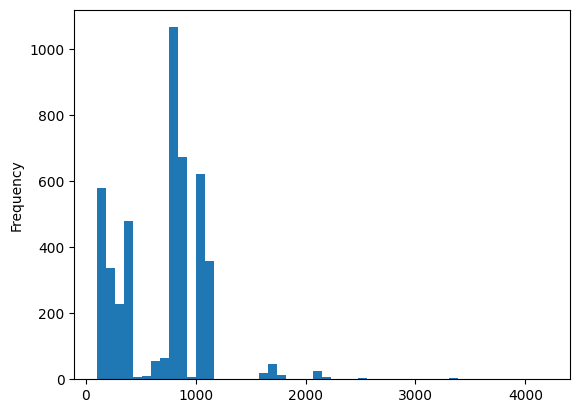

In [117]:
# iii. Plot Histogram on price with bin size 50

items_series_to_rupees.plot(kind='hist', bins=50)

In [118]:
# v, No of items price lies between [1000 to 2000]
items_series_to_rupees.between(1000, 2000).sum()

np.int64(1071)